In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import json
from pathlib import Path
from typing import Dict, List

from src.evaluation import evaluate_run


with open("../data-pollution/.latest_pollutions.json", "r") as f:
    latest = json.load(f)

all_result_folders = []

for folder in latest["polluted_folders"]:
    all_result_folders.extend(
        [
            Path(folder) / "completeness",
            Path(folder) / "consistency",
            Path(folder) / "timeliness",
        ]
    )


datas = []


def work_data(dataset, metric, data, mask, dq_results, dq_certainties):
    datas.append((dataset, metric, data, mask, dq_results, dq_certainties))


for results_folder in all_result_folders:
    if results_folder.exists():
        evaluate_run(results_folder / "results", work_data)

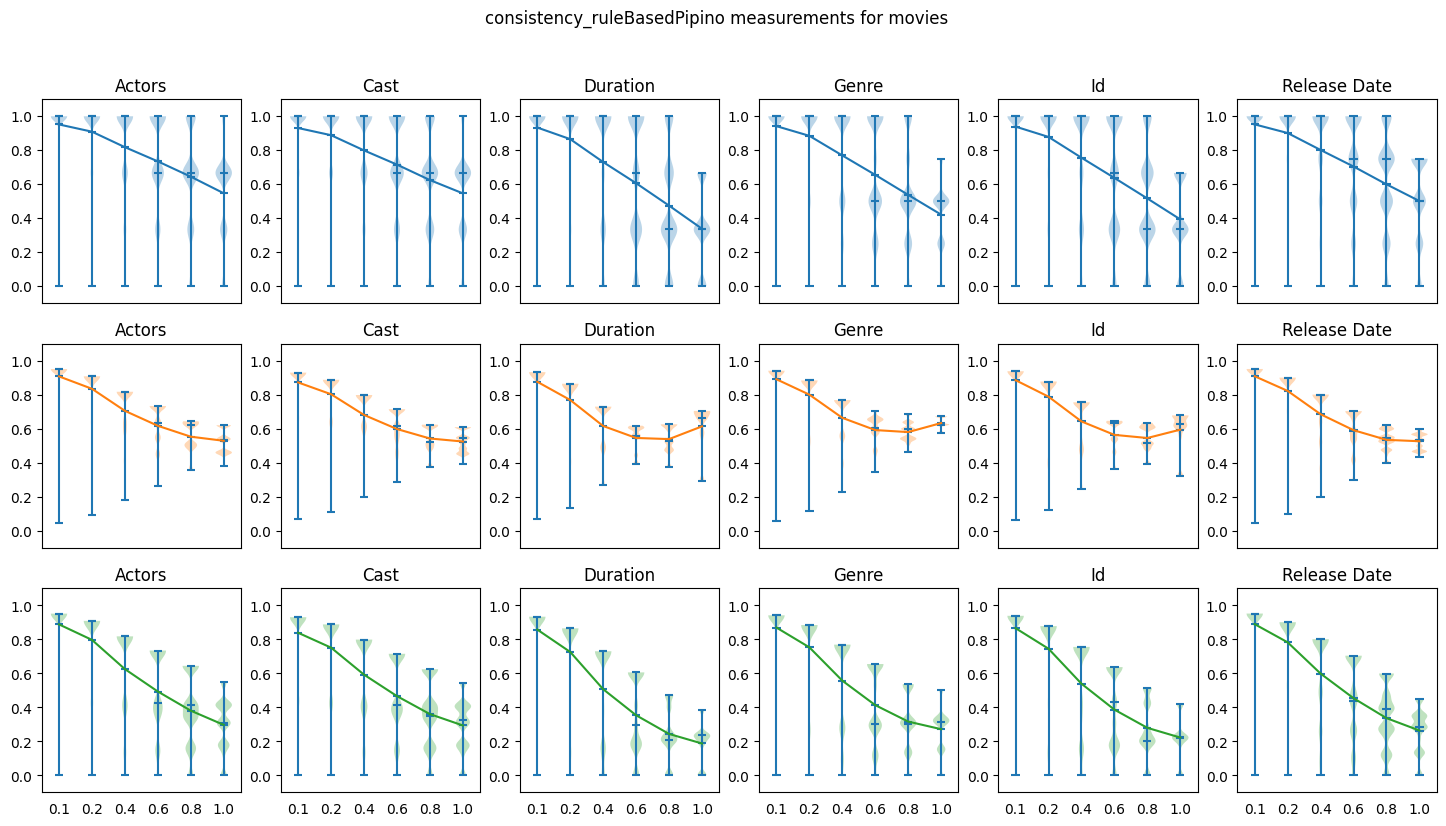

In [ ]:
from src.utils import format_columnName

import numpy as np
import matplotlib.pyplot as plt


nans = [float("nan"), float("nan")]

data_per_metric: Dict[str, Dict[str, Dict[str, Dict[str, List[List[float]]]]]] = {}

for dataset, metric, data, mask, dq_results, dq_certainties in datas:
    dataset_name = dataset.split(".")[0]
    data_per_metric.setdefault(metric, {})
    data_per_metric[metric].setdefault(dataset_name, {})
    for col in dq_results.columns:
        p_rate = (1 - mask[col].mean()).round(2)
        data_per_metric[metric][dataset_name].setdefault(format_columnName(col), {})
        data_per_metric[metric][dataset_name][format_columnName(col)][p_rate] = [
            dq_results[col].to_list(),
            dq_certainties[col].to_list(),
            (dq_results[col] * dq_certainties[col]).to_list(),
            # dq_results[col][mask[col].astype(int) == 1].to_list(),
            # dq_results[col][mask[col].astype(int) < 1].to_list(),
            # dq_certainties[col][mask[col].astype(int) == 1].to_list(),
            # dq_certainties[col][mask[col].astype(int) < 1].to_list(),
        ]

for metric, data in data_per_metric.items():
    for dataset, dataset_data in data.items():
        nrows = len(list(list(dataset_data.values())[0].values())[0])
        ncols = len(dataset_data)
        fig, axes = plt.subplots(
            ncols=ncols, nrows=nrows, figsize=(ncols * 3, nrows * 3), sharex=True
        )

        for row, row_axes in enumerate(axes):
            for col, ax in enumerate(row_axes):
                col_name = list(dataset_data.keys())[col]
                ax.set_title(col_name)
                parts = ax.violinplot(
                    [all_data[row] for all_data in dataset_data[col_name].values()],
                    positions=range(1, len(dataset_data) + 1),
                    showmeans=True,
                    showmedians=True,
                )
                ax.set_ylim(-0.1, 1.1)
                ax.tick_params(axis="x", which="both", bottom=False)
                for pc in parts["bodies"]:  # cmaxes cbars
                    pc.set_facecolor(f"C{row}")

                ax.plot(
                    range(1, len(dataset_data) + 1),
                    [
                        np.mean(all_data[row])
                        for all_data in dataset_data[col_name].values()
                    ],
                    label="Means",
                    color=f"C{row}",
                )
                if row == len(axes) - 1:
                    ax.set_xticks(
                        range(1, len(dataset_data) + 1),
                        labels=dataset_data[col_name].keys(),
                    )

        fig.suptitle(f"{metric} measurements for {dataset}")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_recall_curve, auc

def plot_accuracy_by_threshold(
    dq_results: pd.DataFrame, mask: pd.DataFrame, columns: List[str]
):
    # Accuracy (correctly classified observations) should not be used on imbalanced data
    thresholds = [i / 100 for i in range(0, 101)]
    accuracies_per_column = {}
    for threshold in thresholds:
        accuracy = ((dq_results[columns] >= threshold) == (~mask[columns])).mean()
        for col in accuracy.index:
            accuracies_per_column.setdefault(col, []).append(accuracy[col])

    fig, ax = plt.subplots()

    for col, accuracies in accuracies_per_column.items():
        ax.plot(thresholds, accuracies, label=col)
    ax.set_xlabel("DQ threshold")
    ax.set_ylabel("Accuracy")
    ax.set_title("DQ Accuracy by Threshold")
    ax.grid()
    ax.legend()
    plt.show(fig)


def plot_f1_score_by_threshold(
    dq_results: pd.DataFrame, mask: pd.DataFrame, columns: List[str]
):
    thresholds = [i / 100 for i in range(0, 101)]
    f1_scores_per_column = {}
    for threshold in thresholds:
        predictions = dq_results[columns] >= threshold
        for col in columns:
            f1 = f1_score(~mask[col], predictions[col])
            f1_scores_per_column.setdefault(col, []).append(f1)

    fig, ax = plt.subplots()

    for col, f1_scores in f1_scores_per_column.items():
        ax.plot(thresholds, f1_scores, label=col)
    ax.set_xlabel("DQ threshold")
    ax.set_ylabel("F1 Score")
    ax.set_title("DQ F1 Score by Threshold")
    ax.grid()
    ax.legend()
    plt.show(fig)


def plot_pr_auc_curve(dq_results: pd.DataFrame, mask: pd.DataFrame, columns: List[str]):
    fig, ax = plt.subplots()

    for col in columns:
        precision, recall, t = precision_recall_curve(
            ~mask[col][dq_results[col].dropna().index], dq_results[col].dropna()
        )
        pr_auc = auc(recall, precision)
        ax.plot(recall, precision, label=f"{col} (AUC={pr_auc:.2f})")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve")
    ax.grid()
    ax.legend()
    plt.show(fig)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_recall_curve, auc


def minimum(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    return dq_results.min(axis=0)


def maximum(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    return dq_results.max(axis=0)


def weighted_minimum(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    weighted_results = dq_results * certainties
    return weighted_results.min(axis=0)


def weighted_maximum(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    weighted_results = dq_results * certainties
    return weighted_results.max(axis=0)


def mean(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    return dq_results.mean(axis=0)


def weighted_mean(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    weighted_sums = (dq_results * certainties).sum(axis=0)
    sum_of_weights = certainties.sum(axis=0)
    return weighted_sums / sum_of_weights


def median(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    return dq_results.median(axis=0)


def weighted_median(dq_results: pd.DataFrame, certainties: pd.DataFrame) -> pd.Series:
    weighted_results = dq_results * certainties
    return weighted_results.median(axis=0)


def evaluate_aggregation_methods(
    dq_results: pd.DataFrame, certainties: pd.DataFrame, expected: pd.DataFrame
) -> pd.DataFrame:
    aggregation_methods = [
        minimum,
        maximum,
        weighted_minimum,
        weighted_maximum,
        mean,
        weighted_mean,
        median,
        weighted_median,
    ]

    mse_results = {}
    for method in aggregation_methods:
        aggregated_results = method(dq_results, certainties)
        mse = ((expected - aggregated_results) ** 2).mean()
        mse_results[method.__name__] = mse

    return pd.DataFrame(mse_results)


with pd.option_context("display.expand_frame_repr", False):
    for dataset, metric, data, mask, dq_results, dq_certainties in datas:
        p_rate = 1 - mask.mean().mean()
        eval_df = evaluate_aggregation_methods(
            dq_results, dq_certainties, expected=1 - mask
        )
        print(f"Dataset: {dataset}, Metric: {metric}, Pollution Rate: {p_rate:.2f}")
        print(eval_df)
        print()

Dataset: auto_sales.original, Metric: completeness_nullAndDMVRate, Pollution Rate: 0.00
                                                    minimum  maximum  weighted_minimum  weighted_maximum      mean  weighted_mean  median  weighted_median
ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINE...   0.4225      1.0      1.504121e-07            0.0098  0.876851       0.963246  0.9025         0.002053

Dataset: auto_sales.original, Metric: completeness_nullRate, Pollution Rate: 0.00
                                                    minimum  maximum  weighted_minimum  weighted_maximum  mean  weighted_mean  median  weighted_median
ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINE...      1.0      1.0               1.0               1.0   1.0            1.0     1.0              1.0

Dataset: movies.original, Metric: completeness_nullAndDMVRate, Pollution Rate: 0.00
                                                     minimum  maximum  weighted_minimum  weighted_maximum      mean  weighted_mean  